In [ ]:
!pip -q install ultralytics>=8.2.0 opencv-python==4.10.0.84 scipy numpy matplotlib tqdm ffmpeg-python
import os, sys, math, json, time, shutil
import numpy as np
import cv2
import ffmpeg
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from tqdm import tqdm

from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (10, 4)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import files

uploaded = files.upload()
in_name = list(uploaded.keys())[0]
base = os.path.splitext(os.path.basename(in_name))[0]
norm_name = f"{base}_norm30.mp4"

# Normalize with ffmpeg: fix rotation metadata, set fps 30, scale max width 1280 (keeps aspect), h.264
import subprocess

in_name = list(uploaded.keys())[0]
base = os.path.splitext(os.path.basename(in_name))[0]
norm_name = f"{base}_norm30.mp4"


cmd = [
    "ffmpeg",
    "-y",
    "-i", in_name,
    "-vf", "fps=30,scale=1280:-2",
    "-c:v", "libx264",
    "-preset", "fast",
    "-crf", "23",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    norm_name
]

subprocess.run(cmd, check=True)
print("Normalized video:", norm_name)

print("Normalized video:", norm_name)


Saving IMG_5947.MOV to IMG_5947.MOV
Normalized video: IMG_5947_norm30.mp4
Normalized video: IMG_5947_norm30.mp4


In [ ]:
model = YOLO('yolo11x-pose.pt')


In [ ]:
def angle_deg(a, b, c):
    a, b, c = np.array(a, float), np.array(b, float), np.array(c, float)
    ba = a - b
    bc = c - b
    denom = (np.linalg.norm(ba)*np.linalg.norm(bc) + 1e-6)
    cosang = np.clip(np.dot(ba, bc) / denom, -1.0, 1.0)
    return np.degrees(np.arccos(cosang))

def smooth(x, win=21, poly=3):
    if len(x) < win:
        win = max(5, len(x)//2*2+1)  # make odd and <= len
    return savgol_filter(x, window_length=win, polyorder=min(poly, win-2))

def velocity(x, fps):
    x = np.asarray(x)
    v = np.gradient(x) * fps
    return v

def mid_point(p1, p2):
    return ((p1[0]+p2[0])/2.0, (p1[1]+p2[1])/2.0)

# COCO keypoint indices for YOLO pose (17):
# 0 nose,1 L eye,2 R eye,3 L ear,4 R ear,5 L shoulder,6 R shoulder,
# 7 L elbow,8 R elbow,9 L wrist,10 R wrist,11 L hip,12 R hip,
# 13 L knee,14 R knee,15 L ankle,16 R ankle
L_HIP, R_HIP, L_KNEE, R_KNEE, L_ANKLE, R_ANKLE = 11, 12, 13, 14, 15, 16

def pick_main_person(boxes):
    """Pick the index of the largest bbox (assumes one main walker)."""
    if len(boxes) == 0:
        return None
    areas = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])
    return int(np.argmax(areas))


In [ ]:
def detect_gait_events(y_inv, fps, min_stride_time=0.4):
    """
    y_inv: inverted ankle y (higher = higher in frame)
    Returns dict with indices for HS, TO, HO, TS.
    """
    y_s = smooth(y_inv, win=15, poly=3)
    v = velocity(y_s, fps)
    min_distance = int(min_stride_time * fps)

    hs_idx, _ = find_peaks(y_s, distance=min_distance, prominence=(np.std(y_s)*0.2))
    to_idx, _ = find_peaks(-y_s, distance=min_distance, prominence=(np.std(y_s)*0.2))

    # Heel Off: after a stance (near valley), detect first upward velocity crossing
    ho_idx = []
    for i in to_idx:
        j = i + int(0.05*fps)
        jmax = min(len(v)-1, i + int(0.35*fps))
        cand = np.where(v[j:jmax] > np.std(v)*0.2)[0]
        if len(cand):
            ho_idx.append(j + cand[0])

    # Toe Strike: shortly after HS when |v| small (settling)
    ts_idx = []
    for i in hs_idx:
        j = i + int(0.03*fps)
        jmax = min(len(v)-1, i + int(0.25*fps))
        seg = np.abs(v[j:jmax])
        if len(seg):
            k = np.argmin(seg)  # where vertical velocity is minimal
            ts_idx.append(j + k)

    return dict(HS=np.array(hs_idx), TO=np.array(to_idx), HO=np.array(ho_idx), TS=np.array(ts_idx))


In [ ]:
def compute_phase_durations(events, fps):
    """
    Compute average durations (in seconds) between gait events.
    events: dict with keys HS, TO, HO, TS -> arrays of frame indices
    fps: frames/sec
    """
    results = {}

    HS, TO, HO, TS = events['HS'], events['TO'], events['HO'], events['TS']

    # stance phase: HS -> TO (next TO after HS)
    stance = []
    for h in HS:
        next_to = TO[TO > h]
        if len(next_to):
            stance.append((next_to[0] - h) / fps)
    if stance: results['Stance (HS→TO)'] = np.mean(stance)

    # swing phase: TO -> next HS
    swing = []
    for t0 in TO:
        next_hs = HS[HS > t0]
        if len(next_hs):
            swing.append((next_hs[0] - t0) / fps)
    if swing: results['Swing (TO→HS)'] = np.mean(swing)

    # loading response: HS -> TS
    load = []
    for h in HS:
        next_ts = TS[TS > h]
        if len(next_ts):
            load.append((next_ts[0] - h) / fps)
    if load: results['Loading (HS→TS)'] = np.mean(load)

    # push-off: HO -> TO
    push = []
    for ho in HO:
        next_to = TO[TO > ho]
        if len(next_to):
            push.append((next_to[0] - ho) / fps)
    if push: results['Push-off (HO→TO)'] = np.mean(push)

    return results


In [ ]:
cap = cv2.VideoCapture(norm_name)
assert cap.isOpened(), "Could not open normalized video."

fps = cap.get(cv2.CAP_PROP_FPS)
W  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
nF = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {W}x{H} @ {fps:.1f} fps, frames={nF}")

Lhip, Rhip, Lknee, Rknee, Lank, Rank = [], [], [], [], [], []
Lshoulder, Rshoulder = [], []

frame_ids = []

for fi in tqdm(range(nF)):
    ret, frame = cap.read()
    if not ret: break


    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model.predict(rgb, verbose=False, conf=0.5, iou=0.5, max_det=5)
    res = results[0]

    if (res.boxes is None) or (res.keypoints is None) or (res.boxes.xyxy.shape[0]==0):
        def nanpt(): return (np.nan, np.nan)
        Lhip.append(nanpt()); Rhip.append(nanpt())
        Lknee.append(nanpt()); Rknee.append(nanpt())
        Lank.append(nanpt());  Rank.append(nanpt())
        Lshoulder.append(nanpt()); Rshoulder.append(nanpt())
        frame_ids.append(fi)
        continue

    boxes = res.boxes.xyxy.cpu().numpy()
    kps   = res.keypoints.data.cpu().numpy()  # shape: (n,17,3)

    idx = pick_main_person(boxes)
    if idx is None:
        def nanpt(): return (np.nan, np.nan)
        Lhip.append(nanpt()); Rhip.append(nanpt())
        Lknee.append(nanpt()); Rknee.append(nanpt())
        Lank.append(nanpt());  Rank.append(nanpt())
        Lshoulder.append(nanpt()); Rshoulder.append(nanpt())
        frame_ids.append(fi)
        continue

    kp = kps[idx]
    toxy = lambda p: (float(p[0]), float(p[1]))

    _Lhip, _Rhip = toxy(kp[L_HIP]), toxy(kp[R_HIP])
    _Lk, _Rk     = toxy(kp[L_KNEE]), toxy(kp[R_KNEE])
    _La, _Ra     = toxy(kp[L_ANKLE]), toxy(kp[R_ANKLE])
    _Ls, _Rs     = toxy(kp[5]), toxy(kp[6])

    Lhip.append(_Lhip); Rhip.append(_Rhip)
    Lknee.append(_Lk);  Rknee.append(_Rk)
    Lank.append(_La);   Rank.append(_Ra)
    Lshoulder.append(_Ls); Rshoulder.append(_Rs)
    frame_ids.append(fi)

cap.release()


Lhip = np.array(Lhip); Rhip = np.array(Rhip)
Lknee = np.array(Lknee); Rknee = np.array(Rknee)
Lank = np.array(Lank); Rank = np.array(Rank)
Lshoulder = np.array(Lshoulder); Rshoulder = np.array(Rshoulder)

pelvis = np.array([mid_point(Lhip[i], Rhip[i]) for i in range(len(Lhip))])
shoulder_mid = np.array([mid_point(Lshoulder[i], Rshoulder[i]) for i in range(len(Lshoulder))])

t = np.array(frame_ids)/fps


Video: 1280x2276 @ 30.0 fps, frames=931


100%|██████████| 931/931 [36:16<00:00,  2.34s/it]


In [ ]:
def compute_angles():
    # Hip angle: angle at hip using (shoulder, hip, knee)
    L_hip_angle = [angle_deg(Lshoulder[i], Lhip[i], Lknee[i]) for i in range(len(t))]
    R_hip_angle = [angle_deg(Rshoulder[i], Rhip[i], Rknee[i]) for i in range(len(t))]

    # Knee angle: angle at knee using (hip, knee, ankle)
    L_knee_angle = [angle_deg(Lhip[i], Lknee[i], Lank[i]) for i in range(len(t))]
    R_knee_angle = [angle_deg(Rhip[i], Rknee[i], Rank[i]) for i in range(len(t))]

    # Ankle angle (approx): angle at ankle using (knee, ankle, "virtual point" 20px to right)
    # This approximates dorsiflex/plantarflex qualitatively; for rigorous ankle angles you'd want foot/toe landmarks.
    L_ankle_angle = [angle_deg(Lknee[i], Lank[i], (Lank[i][0]+20, Lank[i][1])) for i in range(len(t))]
    R_ankle_angle = [angle_deg(Rknee[i], Rank[i], (Rank[i][0]+20, Rank[i][1])) for i in range(len(t))]
    return map(np.array, (L_hip_angle, R_hip_angle, L_knee_angle, R_knee_angle, L_ankle_angle, R_ankle_angle))

L_hip, R_hip, L_knee, R_knee, L_ankle, R_ankle = compute_angles()

# Smooth angles for readability
L_hip_s, R_hip_s = smooth(L_hip), smooth(R_hip)
L_knee_s, R_knee_s = smooth(L_knee), smooth(R_knee)
L_ankle_s, R_ankle_s = smooth(L_ankle), smooth(R_ankle)


In [ ]:
to_inv = lambda arr: -arr[:,1]

Lank_y_inv = to_inv(Lank)
Rank_y_inv = to_inv(Rank)

events_L = detect_gait_events(Lank_y_inv, fps)
events_R = detect_gait_events(Rank_y_inv, fps)

# Cadence
hs_times = np.sort(np.concatenate([events_L['HS']/fps, events_R['HS']/fps]))
if len(hs_times) >= 2:
    intervals = np.diff(hs_times)
    inst_cadence_spm = 60.0 / intervals
    cadence_spm = float(np.median(inst_cadence_spm))
else:
    cadence_spm = float('nan')

print(f"Estimated cadence: {cadence_spm:.1f} steps/min (median from heel strikes)")


Estimated cadence: 105.9 steps/min (median from heel strikes)


/tmp/ipython-input-2666534625.py:13: RuntimeWarning: divide by zero encountered in divide
  inst_cadence_spm = 60.0 / intervals


In [ ]:
import pandas as pd

data = {
    "time_s": t,
    "L_hip_deg": L_hip_s, "R_hip_deg": R_hip_s,
    "L_knee_deg": L_knee_s, "R_knee_deg": R_knee_s,
    "L_ankle_deg": L_ankle_s, "R_ankle_deg": R_ankle_s,
    "L_ankle_y_inv": Lank_y_inv, "R_ankle_y_inv": Rank_y_inv,
    "pelvis_y": pelvis[:,1], "pelvis_x": pelvis[:,0]
}
df = pd.DataFrame(data)
events = {
    "L_HS_idx": events_L["HS"], "L_TO_idx": events_L["TO"], "L_HO_idx": events_L["HO"], "L_TS_idx": events_L["TS"],
    "R_HS_idx": events_R["HS"], "R_TO_idx": events_R["TO"], "R_HO_idx": events_R["HO"], "R_TS_idx": events_R["TS"],
}
ev_rows = []
for k,v in events.items():
    for idx in v:
        ev_rows.append({"event": k, "frame": int(idx), "time_s": idx/float(fps)})
ev_df = pd.DataFrame(ev_rows)

angles_csv = f"{base}_angles.csv"
events_csv = f"{base}_events.csv"
keypts_csv = f"{base}_keypoints.csv"

df.to_csv(angles_csv, index=False)
ev_df.to_csv(events_csv, index=False)


raw = pd.DataFrame({
    "time_s": t,
    "Lhip_x": Lhip[:,0], "Lhip_y": Lhip[:,1],
    "Rhip_x": Rhip[:,0], "Rhip_y": Rhip[:,1],
    "Lknee_x": Lknee[:,0], "Lknee_y": Lknee[:,1],
    "Rknee_x": Rknee[:,0], "Rknee_y": Rknee[:,1],
    "Lank_x": Lank[:,0], "Lank_y": Lank[:,1],
    "Rank_x": Rank[:,0], "Rank_y": Rank[:,1],
})
raw.to_csv(keypts_csv, index=False)

angles_csv, events_csv, keypts_csv


('IMG_5947_angles.csv', 'IMG_5947_events.csv', 'IMG_5947_keypoints.csv')

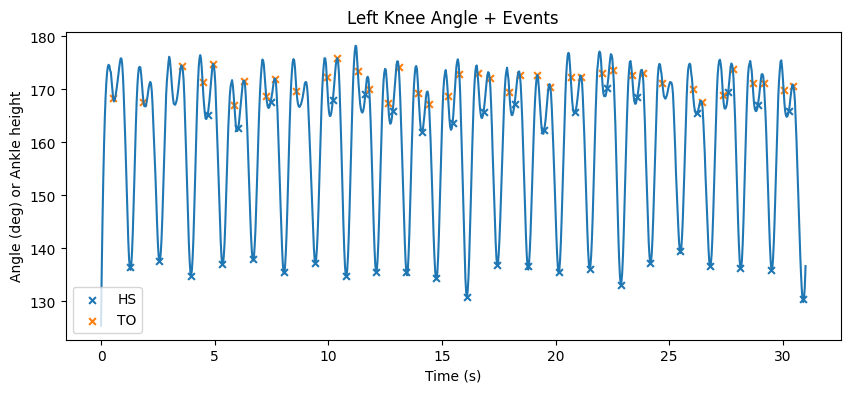

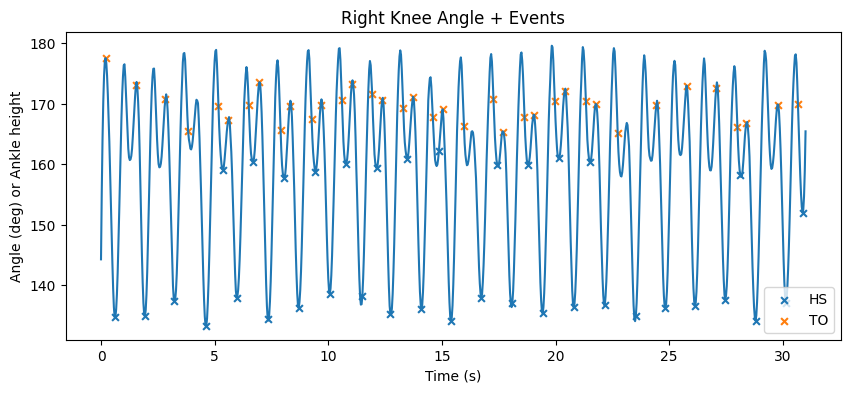

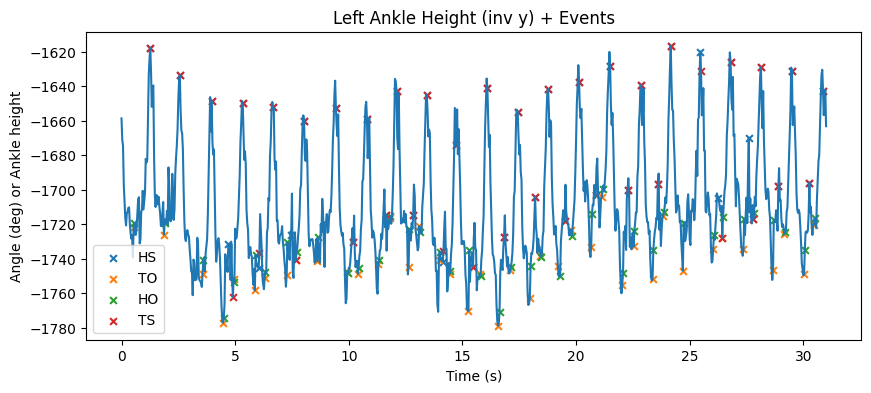

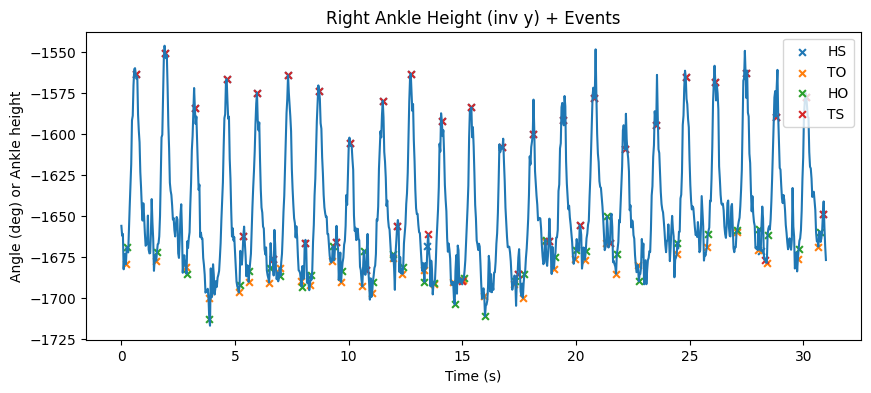

In [ ]:
def plot_with_events(t, y, title, ev_idx_dict):
    plt.figure()
    plt.plot(t, y)
    for name, idxs in ev_idx_dict.items():
        plt.scatter(t[idxs], y[idxs], s=24, label=name, marker='x')
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (deg) or Ankle height')
    plt.legend(loc='best')
    plt.show()

plot_with_events(t, L_knee_s, "Left Knee Angle + Events", {"HS":events_L["HS"], "TO":events_L["TO"]})
plot_with_events(t, R_knee_s, "Right Knee Angle + Events", {"HS":events_R["HS"], "TO":events_R["TO"]})

plot_with_events(t, Lank_y_inv, "Left Ankle Height (inv y) + Events", events_L)
plot_with_events(t, Rank_y_inv, "Right Ankle Height (inv y) + Events", events_R)


In [ ]:
durations_L = compute_phase_durations(events_L, fps)
durations_R = compute_phase_durations(events_R, fps)

print("Average durations (Left foot):")
for k,v in durations_L.items():
    print(f"  {k}: {v:.2f} sec")

print("\nAverage durations (Right foot):")
for k,v in durations_R.items():
    print(f"  {k}: {v:.2f} sec")


Average durations (Left foot):
  Stance (HS→TO): 0.41 sec
  Swing (TO→HS): 0.34 sec
  Loading (HS→TS): 0.67 sec
  Push-off (HO→TO): 0.71 sec

Average durations (Right foot):
  Stance (HS→TO): 0.50 sec
  Swing (TO→HS): 0.35 sec
  Loading (HS→TS): 0.81 sec
  Push-off (HO→TO): 0.81 sec


In [ ]:
cap = cv2.VideoCapture(norm_name)
out_name = f"{base}_annotated.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_name, fourcc, fps, (W,H))

def ev_lookup(ev_dict, radius=2):
    L = {}
    for name, idxs in ev_dict.items():
        for i in idxs:
            for d in range(-radius, radius+1):
                L[i+d] = name
    return L

L_ev = ev_lookup(events_L)
R_ev = ev_lookup(events_R)

kp_names = ['nose','le','re','le','re','Lsho','Rsho','Lelb','Relb','Lw','Rw','Lhip','Rhip','Lknee','Rknee','Lank','Rank']
pairs = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,12),(11,13),(13,15),(12,14),(14,16)]  # shoulders-arms, hips-legs

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
for fi in tqdm(range(nF)):
    ret, frame = cap.read()
    if not ret:
        break

    # draw skeleton for already-computed keypoints if present
    if fi < len(Lank):
        def circ(pt, color=(255,255,255)):
            if not np.any(np.isnan(pt)):
                cv2.circle(frame, (int(pt[0]), int(pt[1])), 4, color, -1)

        # lines (left)
        if not (np.any(np.isnan(Lhip[fi])) or np.any(np.isnan(Lknee[fi]))):
            cv2.line(frame, (int(Lhip[fi][0]),int(Lhip[fi][1])), (int(Lknee[fi][0]),int(Lknee[fi][1])), (0,255,0), 2)
        if not (np.any(np.isnan(Lknee[fi])) or np.any(np.isnan(Lank[fi]))):
            cv2.line(frame, (int(Lknee[fi][0]),int(Lknee[fi][1])), (int(Lank[fi][0]),int(Lank[fi][1])), (0,255,0), 2)

        # lines (right)
        if not (np.any(np.isnan(Rhip[fi])) or np.any(np.isnan(Rknee[fi]))):
            cv2.line(frame, (int(Rhip[fi][0]),int(Rhip[fi][1])), (int(Rknee[fi][0]),int(Rknee[fi][1])), (0,255,0), 2)
        if not (np.any(np.isnan(Rknee[fi])) or np.any(np.isnan(Rank[fi]))):
            cv2.line(frame, (int(Rknee[fi][0]),int(Rknee[fi][1])), (int(Rank[fi][0]),int(Rank[fi][1])), (0,255,0), 2)

        for pt in [Lhip[fi], Rhip[fi], Lknee[fi], Rknee[fi], Lank[fi], Rank[fi]]:
            circ(pt)


        labL = L_ev.get(fi, None)
        labR = R_ev.get(fi, None)
        y0 = 30
        if labL: cv2.putText(frame, f"L {labL}", (20, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2, cv2.LINE_AA); y0+=28
        if labR: cv2.putText(frame, f"R {labR}", (20, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2, cv2.LINE_AA)

        cv2.putText(frame, f"Cadence ~ {cadence_spm:.1f} spm", (W-330, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)

    out.write(frame)

cap.release()
out.release()
print("Wrote:", out_name)


100%|██████████| 931/931 [00:36<00:00, 25.58it/s]

Wrote: IMG_5947_annotated.mp4
